<div align="center">
  <img src="./img/logo.png" />
  <h1><b>5. GeoHawk: Classification</b></h1>
  <p></p>
</div>

In [222]:
import pandas as pd

df = pd.read_csv('data/coordinates.csv')

# Add the filename column to the dataframe (filename is {index}.png)
df['filename'] = df.index.map(lambda x: f'{x}.png')
df.head()

,latitude,longitude,filename
0,20.824885,-98.499517,0.png
1,-3.451752,-54.563937,1.png
2,-23.496464,-47.460542,2.png
3,-16.548678,-72.852778,3.png
4,-35.010870,140.064397,4.png


## **5.1 Classifying geolocation data (latitude and longitude)**
To classify the geolocation of the images, we will need to somehow convert coordinates (lat and lon) to a categorical values

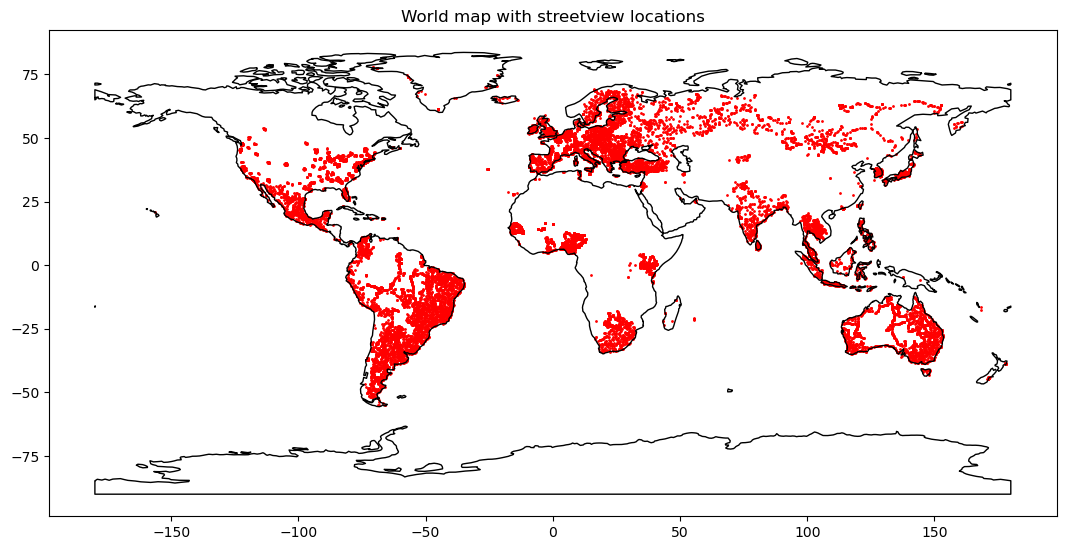

In [223]:
import geopandas as gpd
import geodatasets as gds
import matplotlib.pyplot as plt

# Load a world map
world = gpd.read_file(gds.get_path('naturalearth.land'))

def plot_data_on_world_map(df, clusters=False, marker_size=1, title='World map with streetview locations'):
    # Creating a GeoDataFrame from the DataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude))

    # Plot the data points on top of the world map
    fig, ax = plt.subplots(figsize=(13,13))
    world.boundary.plot(ax=ax, color='black', linewidth=1)

    # Plot the clusters or all points
    if clusters:
        gdf.plot(ax=ax, c=df['cluster'], markersize=marker_size)
    else:
        gdf.plot(ax=ax, color='red', markersize=marker_size)

    plt.title(title)
    plt.show()

plot_data_on_world_map(df)

### **5.1.1 KMeans clustering**
KMeans clustering is a unsupervised method to cluster groups of data points in to clusters. It is a continuous process with the following steps:

1. Select initial cluster center points.
2. Assign data points to the nearest centroid as measured by euclidean distance.
3. Determine new cluster center points.
4. Repeat steps 2-3 as needed to achieve the optimal result.

cluster
4     2416
23    1943
13    1939
28    1619
21    1301
15    1194
11    1155
14    1147
10     997
7      874
17     847
2      814
22     788
1      730
26     680
0      668
19     647
24     565
9      551
5      531
20     531
12     527
3      509
29     508
25     447
16     403
8      386
6      283
18     172
27      57
Name: count, dtype: int64


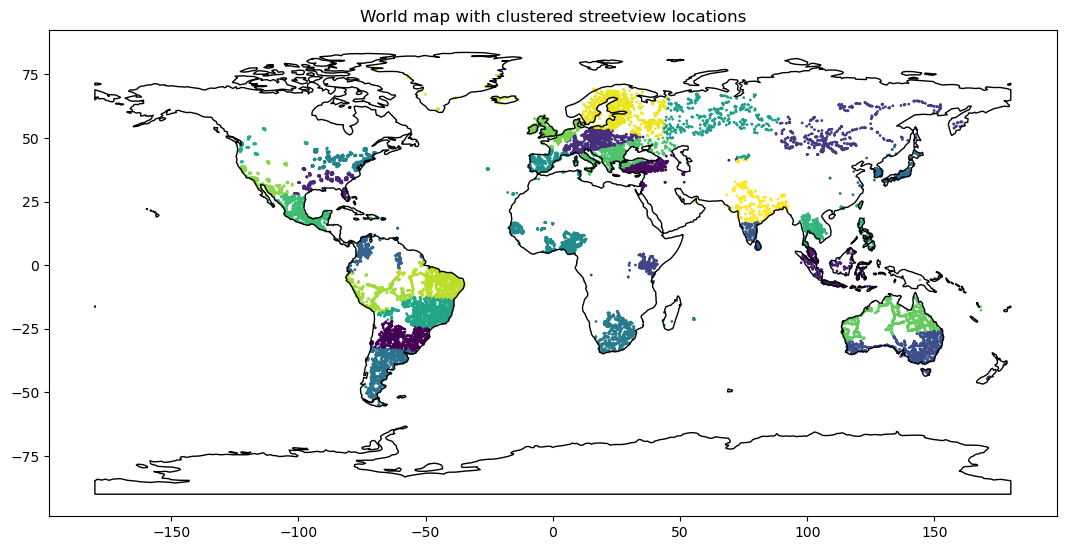

In [224]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Standardize the data
scaler = StandardScaler()
scaled_coords = scaler.fit_transform(df[['latitude', 'longitude']])

# Fit KMeans to the data
num_clusters = 30
kmeans = KMeans(n_clusters=num_clusters, random_state=42)

# Add the cluster labels to the DataFrame
df['cluster'] = kmeans.fit_predict(scaled_coords)
print(df['cluster'].value_counts())

# Plot the data with the clusters
plot_data_on_world_map(df, clusters=True, title='World map with clustered streetview locations')

#### **5.1.1.1 Save cluster geolocations**
To later convert clusters back into a geolocation we can save the cluster center point in a new DataFrame

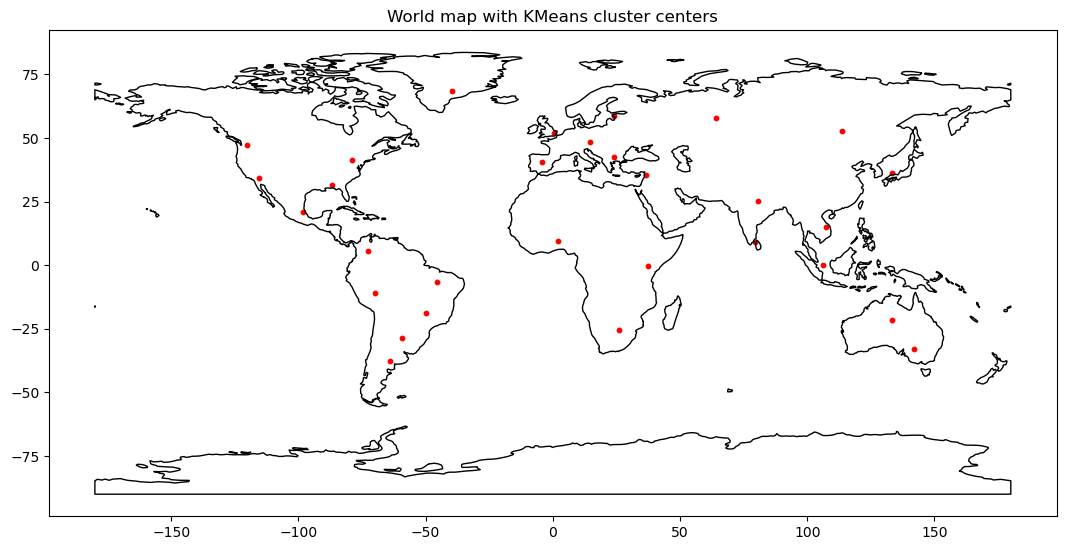

In [225]:
# Create a DataFrame with cluster center points (include cluster labels)
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=['latitude', 'longitude'],
)
cluster_centers['cluster'] = range(num_clusters)

# Plot the data points and cluster centers on the world map
plot_data_on_world_map(cluster_centers, marker_size=10, title='World map with KMeans cluster centers')